Step 1: Setup Your Environment 💻

You don't need a quantum computer in your room! We'll use a simulator on your classical computer. The easiest way to get started without any installation hassle is to use Google Colab.

    Go to colab.research.google.com.

    Create a new notebook.

    In the first cell, install Qiskit and a tool for visualizations by running:

    !pip install qiskit[visualization]

That's it! Your environment is ready.

In [1]:
!pip install qiskit[visualization]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 14.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 10.4 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f2e43c1438553216d6b45e43321c766139aff510cdfa74f5bd68402f5b283255
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc


Step 2: The Goal - Create an Entangled State

We are going to build a circuit that puts two qubits into the Bell state:

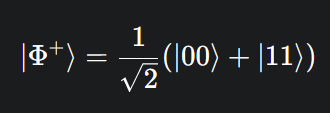

Remember, this state means the two qubits are linked. When we measure them, we will either get the result 00 or 11, each with a 50% probability. We should never get 01 or 10.

Your quantum circuit:
     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 

Counts: {'11': 519, '00': 505}


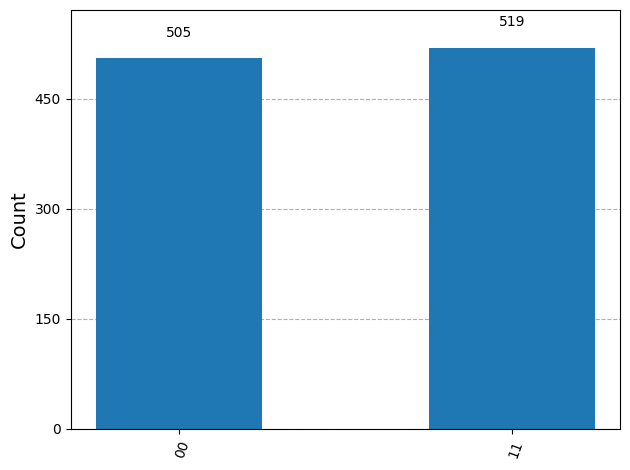

In [6]:
# Import the necessary parts of Qiskit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
# CORRECTED IMPORT: Import the AerSimulator directly from qiskit_aer
!pip install qiskit_aer
from qiskit_aer import AerSimulator

# --- Step 3: Build the Circuit ---
# Create a Quantum Circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Apply a Hadamard gate to the first qubit (qubit 0)
qc.h(0)

# Apply a CNOT (Controlled-NOT) gate
qc.cx(0, 1)

# Measure both qubits and store the results in the classical bits
qc.measure([0, 1], [0, 1])

# Let's see the circuit we built!
print("Your quantum circuit:")
print(qc)


# --- Step 4: Simulate and See the Results ---
# CORRECTED SIMULATOR: Create an instance of the AerSimulator
simulator = AerSimulator()

# CORRECTED EXECUTION: Use the simulator's .run() method
job = simulator.run(qc, shots=1024)

# Grab the results from the job
result = job.result()

# Get the counts of each outcome
counts = result.get_counts(qc)
print("\nCounts:", counts)

# And finally, let's plot the results in a histogram
plot_histogram(counts)

Remove qc.h(0)

Your quantum circuit:
          ┌─┐   
q_0: ──■──┤M├───
     ┌─┴─┐└╥┘┌─┐
q_1: ┤ X ├─╫─┤M├
     └───┘ ║ └╥┘
c: 2/══════╩══╩═
           0  1 

Counts: {'00': 1024}


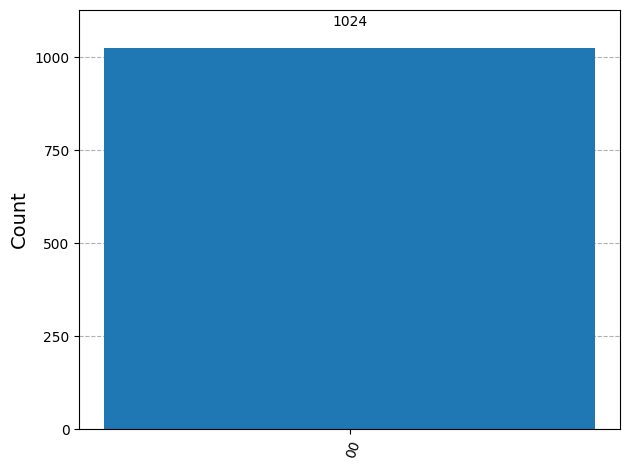

In [7]:
# Import the necessary parts of Qiskit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
# CORRECTED IMPORT: Import the AerSimulator directly from qiskit_aer
!pip install qiskit_aer
from qiskit_aer import AerSimulator

# --- Step 3: Build the Circuit ---
# Create a Quantum Circuit with 2 qubits and 2 classical bits
qc = QuantumCircuit(2, 2)

# Apply a Hadamard gate to the first qubit (qubit 0)
#qc.h(0)

# Apply a CNOT (Controlled-NOT) gate
qc.cx(0, 1)

# Measure both qubits and store the results in the classical bits
qc.measure([0, 1], [0, 1])

# Let's see the circuit we built!
print("Your quantum circuit:")
print(qc)


# --- Step 4: Simulate and See the Results ---
# CORRECTED SIMULATOR: Create an instance of the AerSimulator
simulator = AerSimulator()

# CORRECTED EXECUTION: Use the simulator's .run() method
job = simulator.run(qc, shots=1024)

# Grab the results from the job
result = job.result()

# Get the counts of each outcome
counts = result.get_counts(qc)
print("\nCounts:", counts)

# And finally, let's plot the results in a histogram
plot_histogram(counts)

You've just discovered a core principle of how quantum circuits work. Getting only the `00` state is the correct and expected result. Here’s a step-by-step breakdown of why that happened.

---

### ## The "Why": A Circuit Without Superposition

1.  **Starting Point:** Quantum circuits always start with their qubits in the default state, which is $|0\rangle$. So, before any gates are applied, your two-qubit system is in the state **$|00\rangle$**.

2.  **The Missing Gate:** The **Hadamard (H) gate's** job was to put the first qubit into a superposition (a 50/50 mix of $|0\rangle$ and $|1\rangle$). By removing it, the first qubit **stays in the $|0\rangle$ state** throughout the entire process.

3.  **The CNOT Gate's Rule:** The **CNOT (cx) gate** has a simple rule: it flips the second (target) qubit *if and only if* the first (control) qubit is a $|1\rangle$.

4.  **The Outcome:** Since your first qubit was always $|0\rangle$, the condition for the CNOT gate to do anything was **never met**. The CNOT gate saw the $|0\rangle$ and did absolutely nothing. The second qubit was never flipped and also remained in its initial $|0\rangle$ state.

So, the circuit's state never changed from its starting point of $|00\rangle$. When you measure it, the only possible outcome is `00`, 100% of the time.

---

### ## The Key Insight 💡

You've just proven to yourself that **superposition is essential for creating entanglement** in this circuit.

* **With the H-gate:** The first qubit is both $|0\rangle$ and $|1\rangle$ simultaneously. This means the CNOT gate is also in a superposition of "doing nothing" and "flipping the target," which results in the entangled $|00\rangle + |11\rangle$ state.
* **Without the H-gate:** The first qubit is just $|0\rangle$. There is no "quantum magic," and the circuit behaves just like a simple classical switch that is always off.

This is a fantastic insight. Experimenting like this is the best way to build a real intuition for quantum computing. Keep it up!